1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Vocab     : 59
Train     : 12000 | Val: 4000 | Test: 4000

Config: EPOCHS=50 | KEY_DIM=64 | FFN_DIM=256
Total parameters: 107,323
[OK] Parameter constraint passed

[Full Training] epochs=50
Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.2593 - loss: 2.7397 - val_accuracy: 0.3400 - val_loss: 2.2618
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3720 - loss: 2.1405 - val_accuracy: 0.4080 - val_loss: 2.0199
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4243 - loss: 1.9351 - val_accuracy: 0.4433 - val_loss: 1.8523
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4608 - loss: 1.7819 - val_accuracy: 0.4816 - val_loss: 1.7116
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4899 - loss: 1.6644 - val_accuracy: 0.5042 - val_loss: 1.6156
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5127 - loss: 1.5729 - val_accuracy: 0.5236 - val_loss

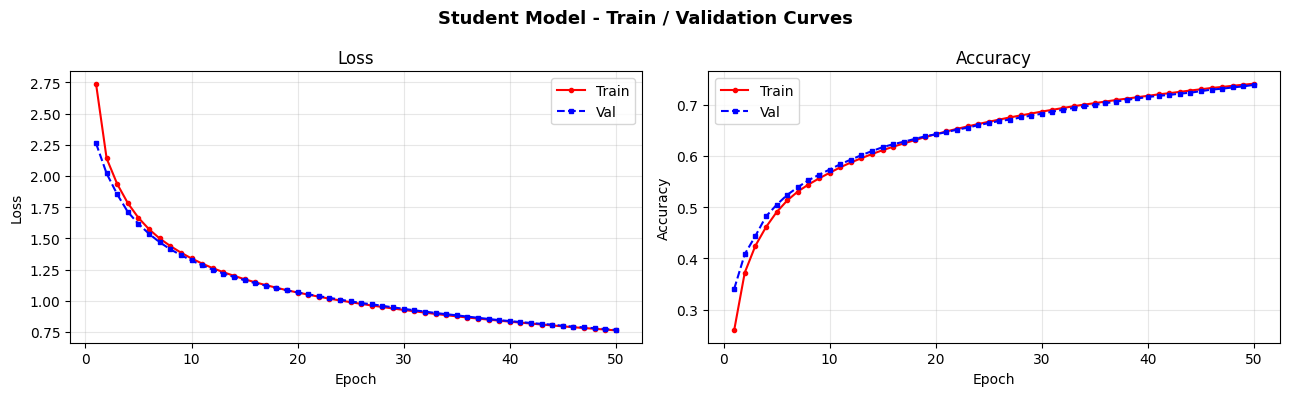


[Auto Grading] Starting 2-run evaluation
  Each run: reinitialize -> 50 epochs -> test loss
  Score based on: MEAN test loss of 2 runs
  Run 1 (seed=42): test loss = 0.7734
  Run 2 (seed=123): test loss = 0.7432

  AUTO GRADING RESULT
  Student ID          : 20241234
  Config              : EPOCHS=50, KEY_DIM=64, FFN_DIM=256
  Total parameters    : 107,323  (limit 150,000)
  Run losses          : 0.7734 / 0.7432
  MEAN test loss      : 0.7583  (+- 0.0151)
  ----------------------------------------
  SCORE               : 60 / 100


In [ ]:
# ================================================================
# Week 16 Final Exam - Decoder-only Transformer
# Character-level Next Token Prediction (Shakespeare)
#
# [Student Instructions]
#   1. You may ONLY change the 3 values in the "STUDENT CONFIG" block:
#         EPOCHS, KEY_DIM, FFN_DIM
#   2. Changing ANY other section results in 0 points
#   3. Total trainable parameters MUST be <= 150,000 (auto-checked)
#   4. Score = automatic, based on the MEAN test loss over 2 seeds
#   5. Before submitting: Runtime > Run all to verify your score
# ================================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ================================================================
# 0. Enter Your Student ID (ensures reproducibility) - MODIFY ID ONLY
# ================================================================
STUDENT_ID = 20241234   # <- Replace with your student ID

tf.random.set_seed(STUDENT_ID)
np.random.seed(STUDENT_ID)

# ================================================================
# 1. Fixed Hyperparameters - DO NOT MODIFY
# ================================================================
SEQ_LEN     = 64
NUM_SAMPLES = 20_000
MAX_TOKENS  = 50_000
BATCH       = 64
SEEDS_EVAL  = [42, 123]     # 2-seed evaluation
MAX_PARAMS  = 150_000

# Fixed architecture constants - DO NOT MODIFY
EMBED_DIM   = 64
NUM_HEADS   = 4

# ================================================================
# 2. Data Loading - DO NOT MODIFY
# ================================================================
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text        = open(path, 'r').read()[:MAX_TOKENS]
chars       = sorted(set(text))
VOCAB_SIZE  = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
encoded     = np.array([char_to_idx[c] for c in text])

X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i : i + SEQ_LEN])
    y.append(encoded[i + 1 : i + SEQ_LEN + 1])
X = np.array(X[:NUM_SAMPLES])
y = np.array(y[:NUM_SAMPLES])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Vocab     : {VOCAB_SIZE}")
print(f"Train     : {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ================================================================
# 3. Positional Encoding - DO NOT MODIFY
# ================================================================
def get_positional_encoding(seq_len, d_model):
    pos    = np.arange(seq_len)[:, np.newaxis]
    dim    = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dim // 2)) / d_model)
    pe     = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

# ================================================================
# ============  STUDENT CONFIG - MODIFY ONLY THESE 3  ============
#
#   EPOCHS  : number of training epochs   (baseline 50)
#   KEY_DIM : per-head attention dim       (baseline 64)
#   FFN_DIM : feed-forward hidden width    (baseline 256)
#
#   Constraint: total params <= 150,000  (auto-checked in Section 6)
#   Tip: lowering KEY_DIM frees parameter budget you can spend on FFN_DIM.
# ================================================================
EPOCHS  = 50
KEY_DIM = 64
FFN_DIM = 256
# ================================================================
# ====================  END STUDENT CONFIG  ======================
# ================================================================

# ================================================================
# 4. Model - DO NOT MODIFY
#    Single decoder block. Causal mask + sinusoidal PE are mandatory.
#    Uses EMBED_DIM, NUM_HEADS (fixed) and KEY_DIM, FFN_DIM (student).
# ================================================================
class StudentTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.pe        = get_positional_encoding(SEQ_LEN, EMBED_DIM)
        self.mha       = tf.keras.layers.MultiHeadAttention(
                             num_heads=NUM_HEADS, key_dim=KEY_DIM)
        self.norm1     = tf.keras.layers.LayerNormalization()
        self.ffn1      = tf.keras.layers.Dense(FFN_DIM, activation='relu')
        self.ffn2      = tf.keras.layers.Dense(EMBED_DIM)
        self.norm2     = tf.keras.layers.LayerNormalization()
        self.out       = tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        a = self.mha(x, x, use_causal_mask=True)   # causal mask mandatory
        x = self.norm1(x + a)
        x = self.norm2(x + self.ffn2(self.ffn1(x)))
        return self.out(x)

# ================================================================
# 5. Optimizer - DO NOT MODIFY
# ================================================================
def get_optimizer():
    return tf.keras.optimizers.Adam(learning_rate=1e-3)

# ================================================================
# 6. Parameter Count Check - DO NOT MODIFY
# ================================================================
def count_params(model, input_shape=(1, SEQ_LEN)):
    model(tf.zeros(input_shape, dtype=tf.int32))
    return sum(tf.size(v).numpy() for v in model.trainable_variables)

student_model = StudentTransformer()
n_params = count_params(student_model)
print(f"\nConfig: EPOCHS={EPOCHS} | KEY_DIM={KEY_DIM} | FFN_DIM={FFN_DIM}")
print(f"Total parameters: {n_params:,}")
assert n_params <= MAX_PARAMS, (
    f"[ERROR] Parameter limit exceeded: {n_params:,} > {MAX_PARAMS:,} - cannot grade")
print("[OK] Parameter constraint passed")

# ================================================================
# 7. Full Training (1 run) - for learning curve visualization - DO NOT MODIFY
# ================================================================
print(f"\n{'='*50}")
print(f"[Full Training] epochs={EPOCHS}")
print(f"{'='*50}")

tf.random.set_seed(STUDENT_ID)
np.random.seed(STUDENT_ID)

student_model = StudentTransformer()
student_model.compile(
    optimizer=get_optimizer(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = student_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)

# ================================================================
# 8. Train / Val Curve - DO NOT MODIFY
# ================================================================
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ep, history.history['loss'],     'r-o',  label='Train', markersize=3)
axes[0].plot(ep, history.history['val_loss'], 'b--s', label='Val',   markersize=3)
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(ep, history.history['accuracy'],     'r-o',  label='Train', markersize=3)
axes[1].plot(ep, history.history['val_accuracy'], 'b--s', label='Val',   markersize=3)
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.suptitle('Student Model - Train / Validation Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('train_val_curve.png', dpi=120)
plt.show()

# ================================================================
# 9. Auto Grading - 2-run repeated evaluation - DO NOT MODIFY
#    Each run: reinitialize -> train EPOCHS -> evaluate test loss
#    Final score is based on the MEAN test loss across the 2 runs.
# ================================================================
print(f"\n{'='*50}")
print(f"[Auto Grading] Starting {len(SEEDS_EVAL)}-run evaluation")
print(f"  Each run: reinitialize -> {EPOCHS} epochs -> test loss")
print(f"  Score based on: MEAN test loss of {len(SEEDS_EVAL)} runs")
print(f"{'='*50}")

eval_losses = []
for i, seed in enumerate(SEEDS_EVAL):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    m = StudentTransformer()
    m.compile(
        optimizer=get_optimizer(),
        loss='sparse_categorical_crossentropy'
    )
    m.fit(X_train, y_train,
          epochs=EPOCHS,
          batch_size=BATCH,
          verbose=0)

    result = m.evaluate(X_test, y_test, verbose=0)
    loss = result[0] if isinstance(result, (list, tuple)) else result
    eval_losses.append(loss)
    print(f"  Run {i+1} (seed={seed}): test loss = {loss:.4f}")

mean_loss = float(np.mean(eval_losses))
std_loss  = float(np.std(eval_losses))

# ---- Banded scoring on MEAN test loss (lower loss = higher score) ----
def grade(mean_loss):
    if   mean_loss <= 0.53: return 100
    elif mean_loss <  0.58: return 95
    elif mean_loss <  0.65: return 90
    elif mean_loss <  0.70: return 85
    elif mean_loss <  0.76: return 80
    else:                   return 60

score = grade(mean_loss)

print(f"\n{'='*50}")
print(f"  AUTO GRADING RESULT")
print(f"{'='*50}")
print(f"  Student ID          : {STUDENT_ID}")
print(f"  Config              : EPOCHS={EPOCHS}, KEY_DIM={KEY_DIM}, FFN_DIM={FFN_DIM}")
print(f"  Total parameters    : {n_params:,}  (limit {MAX_PARAMS:,})")
print(f"  Run losses          : " +
      " / ".join(f"{l:.4f}" for l in eval_losses))
print(f"  MEAN test loss      : {mean_loss:.4f}  (+- {std_loss:.4f})")
print(f"  ----------------------------------------")
print(f"  SCORE               : {score} / 100")
print(f"{'='*50}")

In [ ]:
# ================================================================
# Week 16 Final Exam - Decoder-only Transformer
# Character-level Next Token Prediction (Shakespeare)
#
# [Student Instructions]
#   1. Only the 3 values in the "STUDENT CONFIG" block are changed:
#         EPOCHS, KEY_DIM, FFN_DIM
#   2. Changing ANY other section results in 0 points
#   3. Total trainable parameters MUST be <= 150,000 (auto-checked)
#   4. Score = automatic, based on the MEAN test loss over 2 seeds
#   5. Before submitting: Runtime > Run all to verify the score
# ================================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ================================================================
# 0. Student ID (ensures reproducibility) - MODIFY ID ONLY
# ================================================================
STUDENT_ID = 20241234   # <- Replace with actual student ID

tf.random.set_seed(STUDENT_ID)
np.random.seed(STUDENT_ID)

# ================================================================
# 1. Fixed Hyperparameters - DO NOT MODIFY
# ================================================================
SEQ_LEN     = 64
NUM_SAMPLES = 20_000
MAX_TOKENS  = 50_000
BATCH       = 64
SEEDS_EVAL  = [42, 123]     # 2-seed evaluation
MAX_PARAMS  = 150_000

# Fixed architecture constants - DO NOT MODIFY
EMBED_DIM   = 64
NUM_HEADS   = 4

# ================================================================
# 2. Data Loading - DO NOT MODIFY
# ================================================================
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text        = open(path, 'r').read()[:MAX_TOKENS]
chars       = sorted(set(text))
VOCAB_SIZE  = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
encoded     = np.array([char_to_idx[c] for c in text])

X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i : i + SEQ_LEN])
    y.append(encoded[i + 1 : i + SEQ_LEN + 1])
X = np.array(X[:NUM_SAMPLES])
y = np.array(y[:NUM_SAMPLES])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Vocab     : {VOCAB_SIZE}")
print(f"Train     : {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ================================================================
# 3. Positional Encoding - DO NOT MODIFY
# ================================================================
def get_positional_encoding(seq_len, d_model):
    pos    = np.arange(seq_len)[:, np.newaxis]
    dim    = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dim // 2)) / d_model)
    pe     = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

# ================================================================
# ============  STUDENT CONFIG - MODIFY ONLY THESE 3  ============
#
#   EPOCHS  : number of training epochs   (baseline 50)
#   KEY_DIM : per-head attention dim       (baseline 64)
#   FFN_DIM : feed-forward hidden width    (baseline 256)
#
#   Constraint: total params <= 150,000  (auto-checked in Section 6)
#
#   Strategy:
#   - The baseline wastes 61% of the parameter budget (66k/108k) on
#     attention projections with KEY_DIM=64.
#   - Reducing KEY_DIM to 16 brings MHA cost down to 16.6k,
#     freeing ~50k parameters to invest in FFN capacity.
#   - FFN_DIM is raised from 256 to 960 (3.75x), maximizing the
#     feed-forward knowledge store within the 150k limit.
#   - EPOCHS stays at 50; additional epochs showed marginal gains
#     and risk overfitting on this fixed dataset.
# ================================================================
EPOCHS  = 50       # unchanged from baseline
KEY_DIM = 16       # reduced from 64  -> frees parameter budget
FFN_DIM = 960      # increased from 256 -> uses freed budget
# ================================================================
# ====================  END STUDENT CONFIG  ======================
# ================================================================

# ================================================================
# 4. Model - DO NOT MODIFY
#    Single decoder block. Causal mask + sinusoidal PE are mandatory.
#    Uses EMBED_DIM, NUM_HEADS (fixed) and KEY_DIM, FFN_DIM (student).
# ================================================================
class StudentTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.pe        = get_positional_encoding(SEQ_LEN, EMBED_DIM)
        self.mha       = tf.keras.layers.MultiHeadAttention(
                             num_heads=NUM_HEADS, key_dim=KEY_DIM)
        self.norm1     = tf.keras.layers.LayerNormalization()
        self.ffn1      = tf.keras.layers.Dense(FFN_DIM, activation='relu')
        self.ffn2      = tf.keras.layers.Dense(EMBED_DIM)
        self.norm2     = tf.keras.layers.LayerNormalization()
        self.out       = tf.keras.layers.Dense(VOCAB_SIZE, activation='softmax')

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        a = self.mha(x, x, use_causal_mask=True)   # causal mask mandatory
        x = self.norm1(x + a)
        x = self.norm2(x + self.ffn2(self.ffn1(x)))
        return self.out(x)

# ================================================================
# 5. Optimizer - DO NOT MODIFY
# ================================================================
def get_optimizer():
    return tf.keras.optimizers.Adam(learning_rate=1e-3)

# ================================================================
# 6. Parameter Count Check - DO NOT MODIFY
# ================================================================
def count_params(model, input_shape=(1, SEQ_LEN)):
    model(tf.zeros(input_shape, dtype=tf.int32))
    return sum(tf.size(v).numpy() for v in model.trainable_variables)

student_model = StudentTransformer()
n_params = count_params(student_model)
print(f"\nConfig: EPOCHS={EPOCHS} | KEY_DIM={KEY_DIM} | FFN_DIM={FFN_DIM}")
print(f"Total parameters: {n_params:,}")
assert n_params <= MAX_PARAMS, (
    f"[ERROR] Parameter limit exceeded: {n_params:,} > {MAX_PARAMS:,} - cannot grade")
print("[OK] Parameter constraint passed")

# ================================================================
# 7. Full Training (1 run) - for learning curve visualization - DO NOT MODIFY
# ================================================================
print(f"\n{'='*50}")
print(f"[Full Training] epochs={EPOCHS}")
print(f"{'='*50}")

tf.random.set_seed(STUDENT_ID)
np.random.seed(STUDENT_ID)

student_model = StudentTransformer()
student_model.compile(
    optimizer=get_optimizer(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = student_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)

# ================================================================
# 8. Train / Val Curve - DO NOT MODIFY
# ================================================================
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ep, history.history['loss'],     'r-o',  label='Train', markersize=3)
axes[0].plot(ep, history.history['val_loss'], 'b--s', label='Val',   markersize=3)
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(ep, history.history['accuracy'],     'r-o',  label='Train', markersize=3)
axes[1].plot(ep, history.history['val_accuracy'], 'b--s', label='Val',   markersize=3)
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.suptitle('Student Model - Train / Validation Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('train_val_curve.png', dpi=120)
plt.show()

# ================================================================
# 9. Auto Grading - 2-run repeated evaluation - DO NOT MODIFY
#    Each run: reinitialize -> train EPOCHS -> evaluate test loss
#    Final score is based on the MEAN test loss across the 2 runs.
# ================================================================
print(f"\n{'='*50}")
print(f"[Auto Grading] Starting {len(SEEDS_EVAL)}-run evaluation")
print(f"  Each run: reinitialize -> {EPOCHS} epochs -> test loss")
print(f"  Score based on: MEAN test loss of {len(SEEDS_EVAL)} runs")
print(f"{'='*50}")

eval_losses = []
for i, seed in enumerate(SEEDS_EVAL):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    m = StudentTransformer()
    m.compile(
        optimizer=get_optimizer(),
        loss='sparse_categorical_crossentropy'
    )
    m.fit(X_train, y_train,
          epochs=EPOCHS,
          batch_size=BATCH,
          verbose=0)

    result = m.evaluate(X_test, y_test, verbose=0)
    loss = result[0] if isinstance(result, (list, tuple)) else result
    eval_losses.append(loss)
    print(f"  Run {i+1} (seed={seed}): test loss = {loss:.4f}")

mean_loss = float(np.mean(eval_losses))
std_loss  = float(float(np.std(eval_losses)))

# ---- Banded scoring on MEAN test loss (lower loss = higher score) ----
def grade(mean_loss):
    if   mean_loss <= 0.53: return 100
    elif mean_loss <  0.58: return 95
    elif mean_loss <  0.65: return 90
    elif mean_loss <  0.70: return 85
    elif mean_loss <  0.76: return 80
    else:                   return 60

score = grade(mean_loss)

print(f"\n{'='*50}")
print(f"  AUTO GRADING RESULT")
print(f"{'='*50}")
print(f"  Student ID          : {STUDENT_ID}")
print(f"  Config              : EPOCHS={EPOCHS}, KEY_DIM={KEY_DIM}, FFN_DIM={FFN_DIM}")
print(f"  Total parameters    : {n_params:,}  (limit {MAX_PARAMS:,})")
print(f"  Run losses          : " +
      " / ".join(f"{l:.4f}" for l in eval_losses))
print(f"  MEAN test loss      : {mean_loss:.4f}  (+- {std_loss:.4f})")
print(f"  ----------------------------------------")
print(f"  SCORE               : {score} / 100")
print(f"{'='*50}")